# Creating a custom collision model

In [1]:
from copy import deepcopy

import casadi as ca
import matplotlib.pyplot as plt
import numpy as np

from robot_optimal_trajectory_planning.collision import Capsule, CollisionModel, ConvexPolytope, Link, model_registry
from robot_optimal_trajectory_planning.config import load_config
from robot_optimal_trajectory_planning.ModelBasedPlannerCasadi import ModelBasedPlannerCasadi

In [2]:
# create a planner with the original model
config = load_config(overrides=["solver=ipopt"])
# make sure the relevant settings are as expected
config.robot.collision_model = "capsules"
config.problem.obstacles = []
config.problem.ignore_collisions = False
config.solver.plugin_options["jit"] = False  # we do not want to compile a solver

config.problem.sample_time = 0.1  # 0.1 seconds between discretization time steps
config.problem.prediction_horizon = 15  # plan 15 time steps into the future (1.5 s)

planner_original = ModelBasedPlannerCasadi(config)

In [3]:
# now we want to create a different collision model for our robot

# let's create a collision model with a cuboid as the table, otherwise identical to the "capsules" model


# register the new class so that it can be referred to in the configuration
@model_registry.register("cuboid_table")
class CuboidTableModel(CollisionModel):
    def _build_robot_collision_data(self) -> None:
        # most of this is identical to the capsule collision model

        # prepare vertices for the table cuboid
        table_vertices = []
        for x_corner in [-0.05, 0.05]:
            for y_corner in [-0.05, 0.05]:
                for z_corner in [0.0, -0.5]:
                    table_vertices.append(np.array([x_corner, y_corner, z_corner]).T)

        self._collision_objects = {
            "shoulder": (
                Capsule(radius=0.1, start_point=ca.vcat([0, 0, 0]), end_point=ca.vcat([0, 0, 0.14])),
                Link.SHOULDER,
            ),
            "upper_arm": (
                Capsule(radius=0.05, start_point=ca.vcat([0, 0, 0.14]), end_point=ca.vcat([0.452, 0, 0.14])),
                Link.UPPER_ARM,
            ),
            "elbow": (
                Capsule(radius=0.075, start_point=ca.vcat([0, 0, 0]), end_point=ca.vcat([0, 0, 0.14 + 0.025])),
                Link.UPPER_ARM,
            ),
            "lower_arm": (
                Capsule(radius=0.05, start_point=ca.vcat([0, 0, 0.01]), end_point=ca.vcat([0.39, 0, 0.01])),
                Link.FOREARM,
            ),
            "wrist": (
                Capsule(radius=0.065, start_point=ca.vcat([0, 0, -0.01]), end_point=ca.vcat([0, 0, 0.1333])),
                Link.FOREARM,
            ),
            "hand": (
                Capsule(radius=0.055, start_point=ca.vcat([0, 0, -0.025]), end_point=ca.vcat([0, 0, 0.0997 + 0.188])),
                Link.WRIST_2,
            ),
            "cable": (
                Capsule(radius=0.025, start_point=ca.vcat([0, 0.05, 0.018]), end_point=ca.vcat([-0.1, 0.05, 0.018])),
                Link.WRIST_3,
            ),
            "table": (
                ConvexPolytope(vertices=table_vertices),
                Link.BASE,
            ),
        }
        self._collision_pairs = [
            # avoid robot link self collisions
            ("shoulder", "wrist"),
            ("shoulder", "hand"),
            ("upper_arm", "wrist"),
            ("upper_arm", "hand"),
            ("lower_arm", "hand"),
            ("shoulder", "cable"),
            ("upper_arm", "cable"),
            ("lower_arm", "cable"),
            # avoid collisions with table surface
            ("table", "elbow"),
            ("table", "wrist"),
            ("table", "hand"),
            ("table", "cable"),
        ]

In [4]:
config_new = deepcopy(config)
config_new.robot.collision_model = "cuboid_table"  # specify that our new model is used

planner_new = ModelBasedPlannerCasadi(config_new)

In [5]:
# formulate a planning problem demonstrating the difference
# see other tutorial for problem specification

dt = config.problem.sample_time
H = config.problem.prediction_horizon

# generate a reference position trajectory
v = np.array([0.0, 0.2, -0.2])  # reference moves down into table
p = np.array([0.35, 0.07, 0.10])
t = np.arange(H + 1) * dt  # includes current time (0 s) and all H future time steps
pos_ref = np.array([p + v * tt for tt in t]).T  # constant velocity prediction for the reference position
future_positions = pos_ref[:, 1:]  # the planner needs the reference starting at the first future time step

# constant orientation, given as unit quaternion
future_orientations = np.array([[1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)]] * H).T

# the planner takes references as numpy arrays of shape 3 x H for position and 4 x H for orientation
planner_original.set_reference(future_positions, future_orientations)
planner_new.set_reference(future_positions, future_orientations)

# set an initial state
initial_joint_angles = np.deg2rad([130, -60, 120, -60, -50, -180])  # 6 angles for 6 joints
initial_joint_velocities = np.zeros(6)  # assume robot starts at rest
x0 = np.concat((initial_joint_angles, initial_joint_velocities))  # the state consists of joint angles and velocities
planner_original.set_x0(x0)
planner_new.set_x0(x0)

In [6]:
print("Solve with original planner")
planner_original.solve()
print()
print("Solve with new planner")
planner_new.solve()

Solve with original planner

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

solving took 296.3954560109414 ms

Solve with new planner
solving took 2167.3443589970702 ms


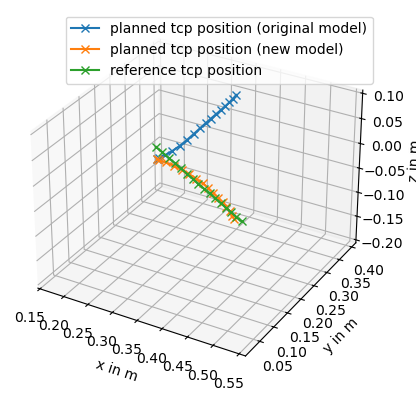

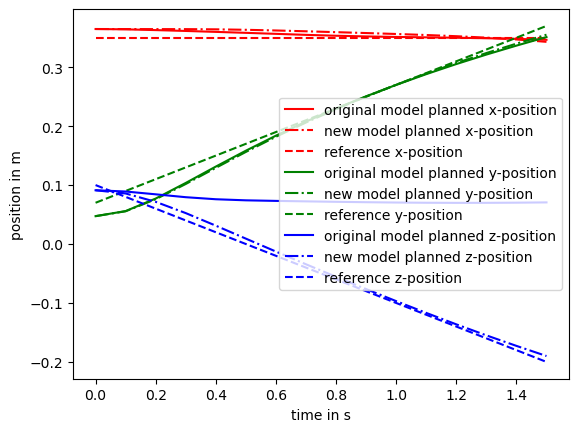

In [7]:
pos_original = planner_original.get_r_sol()
pos_new = planner_new.get_r_sol()
ax = plt.figure().add_subplot(projection="3d")
ax.plot(
    pos_original[0, :], pos_original[1, :], pos_original[2, :], "x-", label="planned tcp position (original model)"
)
ax.plot(pos_new[0, :], pos_new[1, :], pos_new[2, :], "x-", label="planned tcp position (new model)")
ax.plot(pos_ref[0, :], pos_ref[1, :], pos_ref[2, :], "x-", label="reference tcp position")
ax.legend()
ax.set_xlabel("x in m")
ax.set_ylabel("y in m")
ax.set_zlabel("z in m")
plt.axis("equal")
plt.show()

plt.figure()
for dim in range(3):
    plt.plot(t, pos_original[dim, :], "rgb"[dim], label="original model planned " + "xyz"[dim] + "-position")
    plt.plot(t, pos_new[dim, :], "rgb"[dim] + "-.", label="new model planned " + "xyz"[dim] + "-position")
    plt.plot(t, pos_ref[dim, :], "rgb"[dim] + "--", label="reference " + "xyz"[dim] + "-position")
plt.legend()
plt.xlabel("time in s")
plt.ylabel("position in m")
plt.show()

# notice how the original model does not allow the downwards movement but the new model allows the robot to move down
# next to the narrow table